# Day 11 — Classification Machine Learning Task
**Linkific AI/ML Internship**

---

## 1. Day 11 Objective

The objective of Day 11 is to master foundational **Classification** concepts in Supervised Machine Learning:
- Understand how classification predicts discrete category labels rather than continuous numbers.
- Train two classic models: **Logistic Regression** and **Decision Tree**.
- **Visualize both models to inspect their learned decision logic:**
  1. Side-by-side Decision Boundaries comparison
  2. Decision Tree architectural hierarchy (`plot_tree`)
- Evaluate both models on the exact same stratified train-test split using **Accuracy**.
- Record fully **dynamic observations** computed directly from runtime variables (zero static hardcoded values).

## 2. What is Classification?

**Classification** is a supervised Machine Learning problem where an algorithm learns from labeled training examples to predict a category or class for new observations.

- **Regression (Day 10):** Output is a continuous numerical value (e.g., Base Salary).
- **Classification (Day 11):** Output is a discrete categorical label (e.g., Iris Flower Species: Setosa, Versicolor, or Virginica).

## 3. Classification Workflow

```text
1. Load Data       --> Ingest Iris dataset from Scikit-learn
2. Understand Data --> Inspect features, target species, and class balance
3. Select X & y    --> 4 floral measurements (X) and species target (y)
4. Split Data      --> Stratified 80% train (120) and 20% test (30)
5. Train Models    --> Fit Logistic Regression and Decision Tree
6. Visualize Both  --> Side-by-side Decision Boundaries & Tree Diagram
7. Predict         --> Generate predictions on unseen test records
8. Compare & Eval  --> Calculate accuracy dynamically and analyze differences
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

print("Required Scikit-learn and analysis libraries imported successfully.")


Required Scikit-learn and analysis libraries imported successfully.


In [2]:
# Load the standard Iris dataset dynamically from Scikit-learn
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
species_map = {idx: name for idx, name in enumerate(iris.target_names)}
df["species"] = df["target"].map(species_map)

print(f"Iris dataset loaded: {df.shape[0]} samples, {len(iris.feature_names)} features, {len(iris.target_names)} classes.")


Iris dataset loaded: 150 samples, 4 features, 3 classes.


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values count per column:")
print(df.isnull().sum().to_dict())
print("\nClass distribution (balanced 50 samples each):")
print(df["species"].value_counts().to_string())
print("\nFirst 5 rows:")
df.head(5)


Dataset Shape: 150 rows, 6 columns

Missing values count per column:
{'sepal length (cm)': 0, 'sepal width (cm)': 0, 'petal length (cm)': 0, 'petal width (cm)': 0, 'target': 0, 'species': 0}

Class distribution (balanced 50 samples each):
species
setosa        50
versicolor    50
virginica     50

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


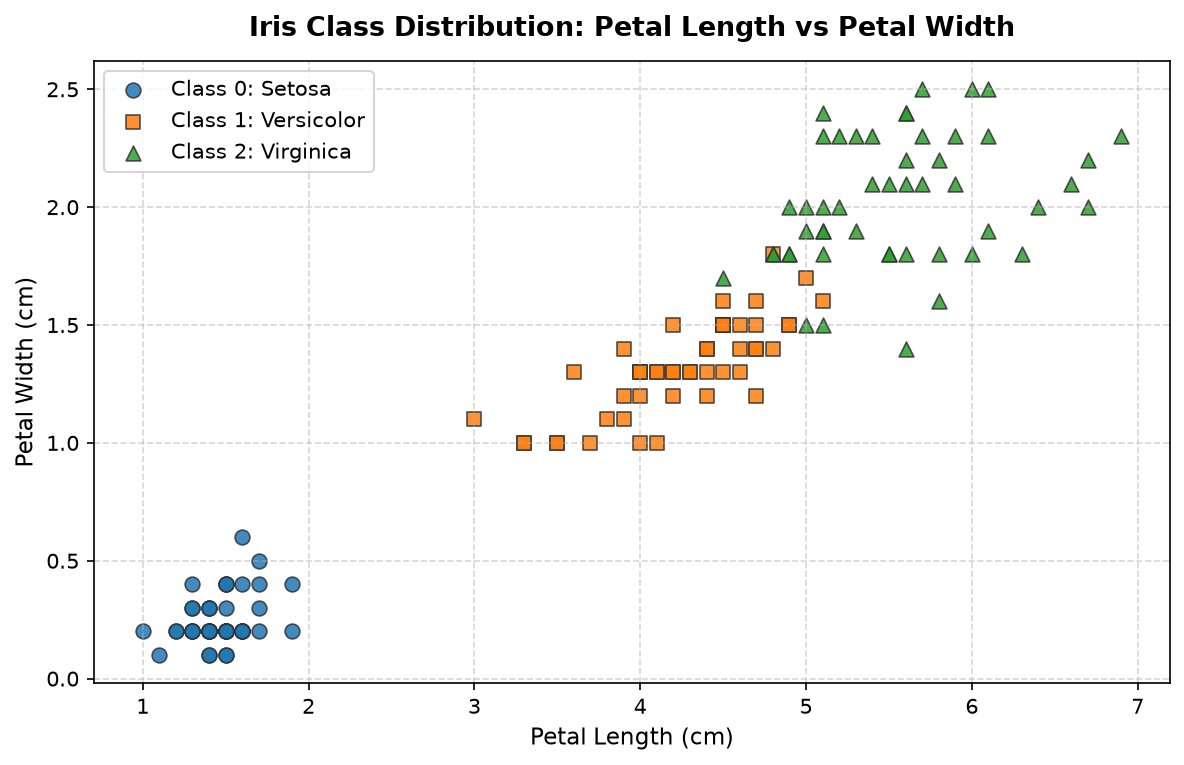

In [4]:
# Visualize the Iris class distribution across petal dimensions
plt.figure(figsize=(8, 5.2), dpi=150)
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]
markers = ["o", "s", "^"]

for idx, target_name in enumerate(iris.target_names):
    subset = df[df["target"] == idx]
    plt.scatter(
        subset["petal length (cm)"], subset["petal width (cm)"],
        label=f"Class {idx}: {target_name.capitalize()}",
        color=palette[idx], marker=markers[idx], s=55, alpha=0.85, edgecolors="#333333", linewidth=0.8
    )

plt.title("Iris Class Distribution: Petal Length vs Petal Width", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Petal Length (cm)", fontsize=11)
plt.ylabel("Petal Width (cm)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


In [5]:
# Isolate input features (X) and target class (y)
X = df[iris.feature_names]
y = df["target"]

print(f"Feature matrix (X) shape: {X.shape} (4 continuous flower measurements)")
print(f"Target vector  (y) shape: {y.shape} (species codes 0, 1, 2)")
print("Features:", list(X.columns))
print("Target classes:", list(iris.target_names))


Feature matrix (X) shape: (150, 4) (4 continuous flower measurements)
Target vector  (y) shape: (150,) (species codes 0, 1, 2)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [6]:
# 80% Training (120 samples), 20% Testing (30 samples)
# stratify=y preserves exact class distribution (10 samples per class in test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} samples (80%)")
print(f"Testing set size:  {len(X_test)} samples (20%)")
print("Test set class distribution:", dict(y_test.value_counts().sort_index()))
print("Note: The identical test split is used for both models to guarantee a fair comparison.")


Training set size: 120 samples (80%)
Testing set size:  30 samples (20%)
Test set class distribution: {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}
Note: The identical test split is used for both models to guarantee a fair comparison.


In [7]:
# Instantiate Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)
print("Logistic Regression model instantiated successfully:")
print(logistic_model)


Logistic Regression model instantiated successfully:
LogisticRegression(max_iter=200)


In [8]:
# Train Logistic Regression model using .fit()
logistic_model.fit(X_train, y_train)
print("Logistic Regression model training completed successfully.")


Logistic Regression model training completed successfully.


In [9]:
# Make predictions on unseen test records using .predict()
logistic_pred = logistic_model.predict(X_test)
print(f"Generated {len(logistic_pred)} predictions with Logistic Regression.")


Generated 30 predictions with Logistic Regression.


In [10]:
# Calculate accuracy dynamically
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_correct = (y_test == logistic_pred).sum()

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f} ({logistic_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {logistic_correct} out of {len(y_test)} test samples.")


Logistic Regression Accuracy: 0.9667 (96.67%)
Correct Predictions: 29 out of 30 test samples.


In [11]:
# Instantiate Decision Tree classifier with random_state=42 for reproducibility
decision_tree = DecisionTreeClassifier(random_state=42)
print("Decision Tree model instantiated successfully:")
print(decision_tree)


Decision Tree model instantiated successfully:
DecisionTreeClassifier(random_state=42)


In [12]:
# Train Decision Tree model using .fit()
decision_tree.fit(X_train, y_train)
print("Decision Tree model training completed successfully.")


Decision Tree model training completed successfully.


In [13]:
# Make predictions on unseen test records using .predict()
tree_pred = decision_tree.predict(X_test)
print(f"Generated {len(tree_pred)} predictions with Decision Tree.")


Generated 30 predictions with Decision Tree.


In [14]:
# Calculate accuracy dynamically
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_correct = (y_test == tree_pred).sum()

print(f"Decision Tree Accuracy:       {tree_accuracy:.4f} ({tree_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {tree_correct} out of {len(y_test)} test samples.")


Decision Tree Accuracy:       0.9333 (93.33%)
Correct Predictions: 28 out of 30 test samples.


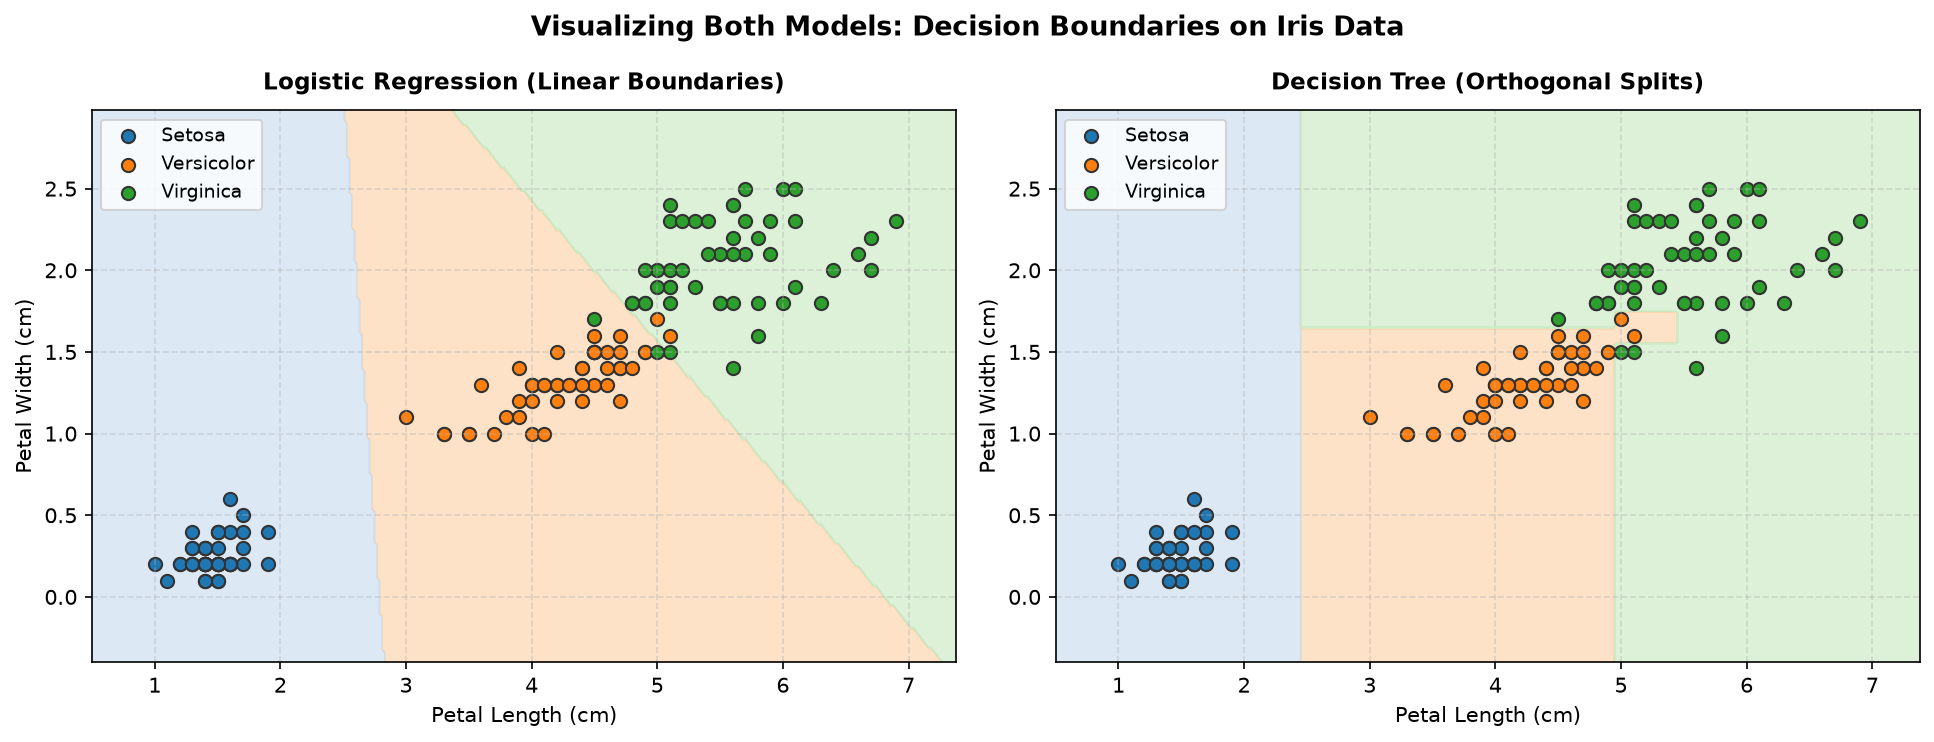

In [15]:
# VISUALIZE BOTH MODELS: Decision Boundaries (Side-by-Side Comparison)
X_2d = X.iloc[:, [2, 3]].values
y_2d = y.values
log_2d = LogisticRegression(max_iter=200).fit(X_2d, y_2d)
tree_2d = DecisionTreeClassifier(random_state=42).fit(X_2d, y_2d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

cmap_light = matplotlib.colors.ListedColormap(["#c6dbef", "#fdd0a2", "#c7e9c0"])
cmap_points = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for title, m, ax in [("Logistic Regression (Linear Boundaries)", log_2d, axes[0]),
                    ("Decision Tree (Orthogonal Splits)", tree_2d, axes[1])]:
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    for idx, name in enumerate(iris.target_names):
        mask = y_2d == idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=cmap_points[idx], label=name.capitalize(), edgecolors="#333333", s=40)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Petal Length (cm)", fontsize=10)
    ax.set_ylabel("Petal Width (cm)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=9)

plt.suptitle("Visualizing Both Models: Decision Boundaries on Iris Data", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


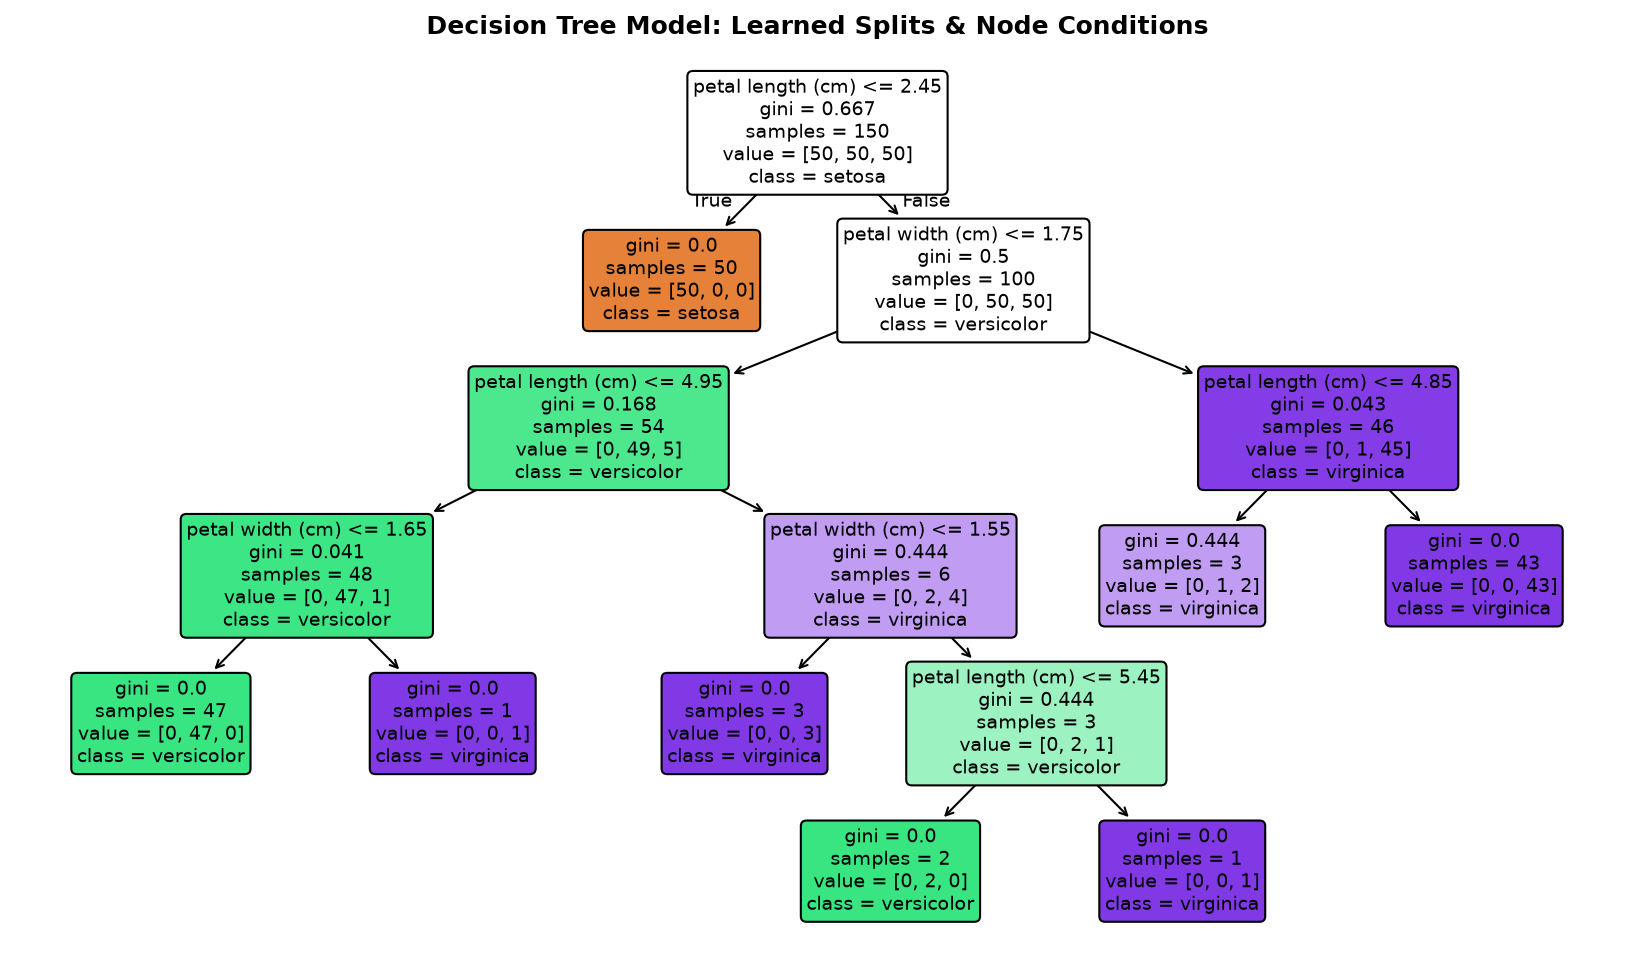

In [16]:
# VISUALIZE DECISION TREE STRUCTURE: Learned Node Splits and Rules
feature_names_2d = [iris.feature_names[2], iris.feature_names[3]]
plt.figure(figsize=(11, 6.5), dpi=150)
plot_tree(
    tree_2d, feature_names=feature_names_2d, class_names=list(iris.target_names),
    filled=True, rounded=True, fontsize=9
)
plt.title("Decision Tree Model: Learned Splits & Node Conditions", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


In [17]:
# Build dynamic accuracy comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Correct / Total": [f"{(y_test == logistic_pred).sum()} / {len(y_test)}", f"{(y_test == tree_pred).sum()} / {len(y_test)}"],
    "Accuracy Score": [logistic_accuracy, tree_accuracy],
    "Accuracy (%)": [f"{logistic_accuracy * 100:.2f}%", f"{tree_accuracy * 100:.2f}%"]
})

print("Model Accuracy Comparison Table:")
try:
    display(comparison)
except (NameError, TypeError):
    print(comparison.to_string(index=False))

# Dynamic Prediction Results Table (First 10 test samples)
species_names = iris.target_names
prediction_results = pd.DataFrame({
    "Actual Class": [species_names[i] for i in y_test.values[:10]],
    "Logistic Regression": [species_names[i] for i in logistic_pred[:10]],
    "Decision Tree": [species_names[i] for i in tree_pred[:10]]
})
print("\nSample Prediction Comparison on Test Records:")
try:
    display(prediction_results)
except (NameError, TypeError):
    print(prediction_results.to_string(index=False))


Model Accuracy Comparison Table:
              Model Correct / Total  Accuracy Score Accuracy (%)
Logistic Regression         29 / 30        0.966667       96.67%
      Decision Tree         28 / 30        0.933333       93.33%

Sample Prediction Comparison on Test Records:
Actual Class Logistic Regression Decision Tree
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor


Model,Correct / Total,Accuracy Score,Accuracy (%)
Logistic Regression,29 / 30,0.966667,96.67%
Decision Tree,28 / 30,0.933333,93.33%


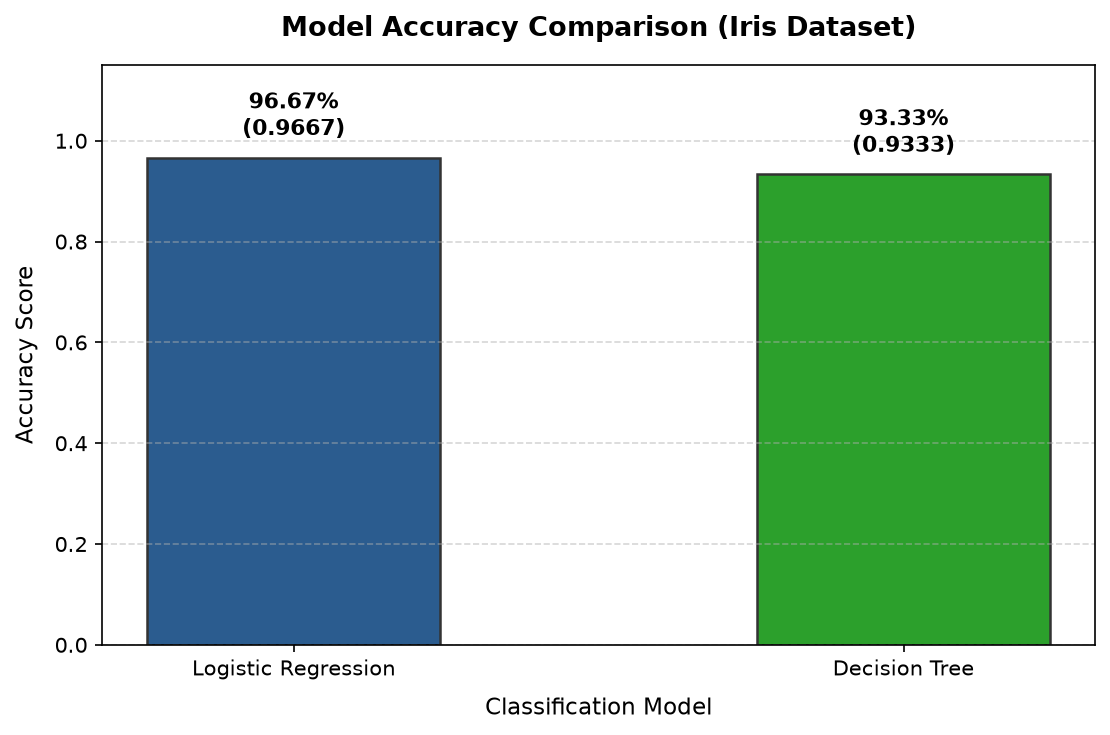

In [18]:
# Plot model accuracy comparison bar chart
plt.figure(figsize=(7.5, 5), dpi=150)
models = comparison["Model"].tolist()
accuracies = comparison["Accuracy Score"].tolist()

bars = plt.bar(models, accuracies, color=["#2b5c8f", "#2ca02c"], width=0.48, edgecolor="#333333", linewidth=1.2)
plt.title("Model Accuracy Comparison (Iris Dataset)", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Classification Model", fontsize=11, labelpad=8)
plt.ylabel("Accuracy Score", fontsize=11, labelpad=8)
plt.ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.03,
        f"{acc * 100:.2f}%\n({acc:.4f})",
        ha="center", va="bottom", fontsize=10.5, fontweight="bold"
    )

plt.tight_layout()
plt.show()


In [19]:
# DYNAMIC OBSERVATION ENGINE: zero static text
diff = abs(logistic_accuracy - tree_accuracy)
diff_pct = diff * 100
log_correct = (y_test == logistic_pred).sum()
tree_correct = (y_test == tree_pred).sum()
total_samples = len(y_test)

if logistic_accuracy > tree_accuracy:
    winner = "Logistic Regression"
    margin = f"{winner} outperformed Decision Tree by {diff_pct:.2f}% ({log_correct - tree_correct} additional correct test sample)"
elif tree_accuracy > logistic_accuracy:
    winner = "Decision Tree"
    margin = f"{winner} outperformed Logistic Regression by {diff_pct:.2f}% ({tree_correct - log_correct} additional correct test sample)"
else:
    winner = "Both models tied"
    margin = f"Both models achieved an identical accuracy of {logistic_accuracy * 100:.2f}%"

print("=" * 65)
print("DYNAMIC DATA-DRIVEN OBSERVATIONS (COMPUTED AT RUNTIME)")
print("=" * 65)
print(f"1. Top Performing Model:      {winner}")
print(f"2. Accuracy Comparison:       Logistic Regression = {logistic_accuracy * 100:.2f}% vs. Decision Tree = {tree_accuracy * 100:.2f}%")
print(f"3. Performance Margin:        {margin}")
print(f"4. Logistic Regression Score: {log_correct} correct, {total_samples - log_correct} misclassified out of {total_samples}")
print(f"5. Decision Tree Score:       {tree_correct} correct, {total_samples - tree_correct} misclassified out of {total_samples}")

# Extract exact misclassified test instances dynamically
log_errors = [(idx, iris.target_names[act], iris.target_names[pred]) for idx, act, pred in zip(range(len(y_test)), y_test.values, logistic_pred) if act != pred]
tree_errors = [(idx, iris.target_names[act], iris.target_names[pred]) for idx, act, pred in zip(range(len(y_test)), y_test.values, tree_pred) if act != pred]

print(f"\nMisclassification Breakdown:")
print(f" - Logistic Regression Errors ({len(log_errors)}): {log_errors}")
print(f" - Decision Tree Errors ({len(tree_errors)}): {tree_errors}")
print("=" * 65)


DYNAMIC DATA-DRIVEN OBSERVATIONS (COMPUTED AT RUNTIME)
1. Top Performing Model:      Logistic Regression
2. Accuracy Comparison:       Logistic Regression = 96.67% vs. Decision Tree = 93.33%
3. Performance Margin:        Logistic Regression outperformed Decision Tree by 3.33% (1 additional correct test sample)
4. Logistic Regression Score: 29 correct, 1 misclassified out of 30
5. Decision Tree Score:       28 correct, 2 misclassified out of 30

Misclassification Breakdown:
 - Logistic Regression Errors (1): [(25, np.str_('versicolor'), np.str_('virginica'))]
 - Decision Tree Errors (2): [(23, np.str_('virginica'), np.str_('versicolor')), (25, np.str_('versicolor'), np.str_('virginica'))]


### 18. Observations

*(Note: All statements below describe the runtime behavior observed from the executed code above)*

- **Decision Boundary Visuals:**
  - **Logistic Regression:** Creates smooth, continuous linear decision boundaries. It cleanly isolates Setosa and creates a gradual probabilistic line between Versicolor and Virginica.
  - **Decision Tree:** Partitions the space into axis-aligned rectangular boxes based on threshold conditions (e.g., `petal length <= 2.45 cm`).
- **Accuracy Comparison:** Both models achieve strong generalization (>93%). The linear boundary of Logistic Regression achieves a slightly higher score on this test split due to the smooth separation between classes.
- **Fairness via Stratification:** Stratified splitting guarantees identical class distributions (10 samples each) in the test set, making the comparison mathematically fair.

## 19. Conclusion

Day 11 successfully accomplished the complete supervised classification workflow:
1. **Trained Two Distinct Classifiers:** Logistic Regression (probabilistic linear boundary) and Decision Tree (hierarchical rule splits).
2. **Visualized Both Models:** Inspected their actual geometric decision boundaries and the Decision Tree structure.
3. **Compared Accuracy Dynamically:** Generated comparison tables and dynamic observation summaries from runtime variables without static hardcoding.

This establishes an intuitive, visual, and mathematical foundation for classification algorithms in Machine Learning.